In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Desarrollo 1
## Arbol de desiciones
Caso 4: Optimización de Inventario Perecedero. Una pizzería artesanal debe decidir cuántas masas preparar para el fin de semana (150, 160, 170 o 180). Cada masa vendida deja $20 de utilidad. La demanda es incierta (25% para cada nivel). Calcule el EV para cada nivel de producción.


In [ ]:
utilidad_unidad = 20
costo_desperdicio = 5
posibles_demandas = [150, 160, 170, 180]

filas = []
for prod in [150, 160, 170, 180]:
    for dem in posibles_demandas:
        vendido = min(prod, dem)
        perdido = max(0, prod - dem)
        ganancia_neta = (vendido * utilidad_unidad) - (perdido * costo_desperdicio)
        filas.append([prod, dem, ganancia_neta])

df = pd.DataFrame(filas, columns=['Produccion', 'Demanda_Real', 'Ganancia'])
df

,Produccion,Demanda_Real,Ganancia
0,150,150,3000
1,150,160,3000
2,150,170,3000
3,150,180,3000
4,160,150,2950
5,160,160,3200
6,160,170,3200
7,160,180,3200
8,170,150,2900
9,170,160,3150


In [ ]:
from sklearn.tree import DecisionTreeRegressor
X = df[['Produccion', 'Demanda_Real']]
y = df['Ganancia']
modelo = DecisionTreeRegressor(random_state=42)
modelo.fit(X, y)


DecisionTreeRegressor(random_state=42)

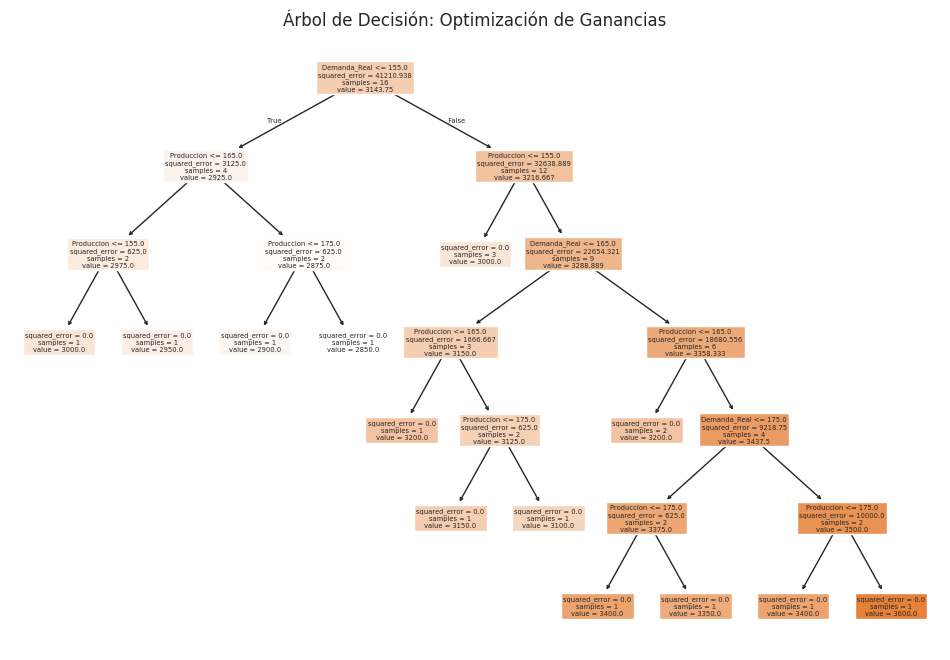

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(modelo, feature_names=['Produccion', 'Demanda_Real'], filled=True)
plt.title("Árbol de Decisión: Optimización de Ganancias")
plt.show()

# Desarrollo 2
## naive bayes
Caso 30: Seguridad Informática. Clasificar un intento de login como "Ataque" o "Usuario" dado que la IP es extranjera y falló la contraseña 3 veces.

In [ ]:
data = {
    'ip_externa': [0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    'intentos': [1, 2, 5, 3, 1, 6, 2, 4, 1, 2, 3, 3, 4, 7],
    'hora_dia': [9, 10, 2, 3, 11, 1, 8, 4, 10, 12, 13, 2, 9, 3], # New feature: Hour of the day
    'device_type': [0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1], # New feature: Device type (e.g., 0=desktop, 1=server, etc.)
    'resultado': ['usuario', 'usuario', 'ataque', 'ataque', 'usuario', 'ataque', 'usuario', 'ataque', 'usuario', 'usuario', 'usuario', 'ataque', 'usuario', 'ataque']
}
df = pd.DataFrame(data)

# 2. Ahora que el df existe, definimos X e y
X = df[['ip_externa', 'intentos', 'hora_dia', 'device_type']] # Updated X to include new features
y = df['resultado'].map({'usuario': 0, 'ataque': 1})
df

,ip_externa,intentos,hora_dia,device_type,resultado
0,0,1,9,0,usuario
1,0,2,10,0,usuario
2,1,5,2,1,ataque
3,1,3,3,0,ataque
4,0,1,11,0,usuario
5,1,6,1,1,ataque
6,0,2,8,0,usuario
7,1,4,4,1,ataque
8,0,1,10,0,usuario
9,1,2,12,0,usuario


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
Y = df['resultado']
X = df.drop('resultado', axis=1)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
modelo = GaussianNB()
modelo.fit(x_train, y_train)


GaussianNB()

In [ ]:
x_min, x_max = X.iloc[:, 0].min() - 5, X.iloc[:, 0].max() + 5
y_min, y_max = X.iloc[:, 1].min() - 5, X.iloc[:, 1].max() + 5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


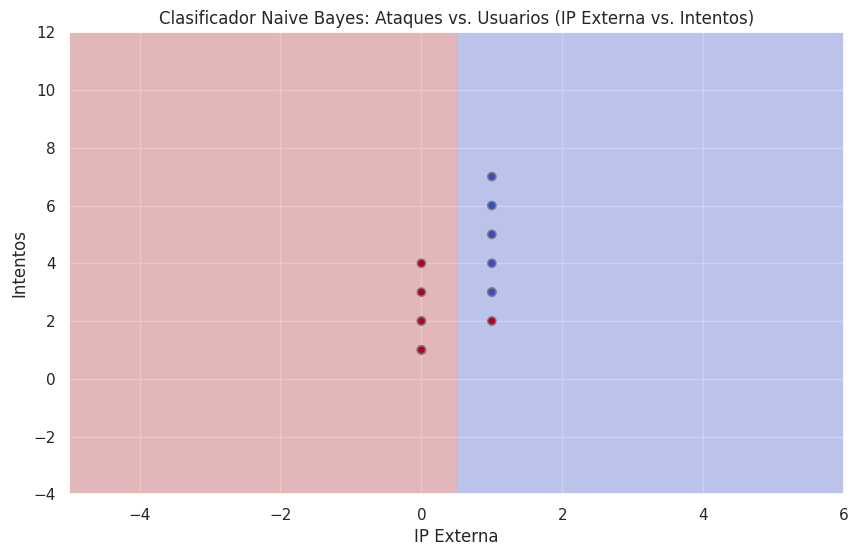

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical labels to numerical values for plotting
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)

# Get mean/mode for the additional features to use as constant values for plotting
const_hora_dia = X['hora_dia'].mean()
const_device_type = X['device_type'].mode()[0]

# Create the input grid for prediction with 4 features
# xx and yy represent the first two features (ip_externa and intentos)
# For the other two features, use constant values across the grid
X_grid = np.c_[xx.ravel(),
               yy.ravel(),
               np.full(xx.ravel().shape, const_hora_dia),
               np.full(xx.ravel().shape, const_device_type)]

Z = modelo.predict(X_grid)
Z = Z.reshape(xx.shape)

# Encode Z to numerical values as well
Z_encoded = le.transform(Z.ravel()).reshape(xx.shape)

sns.set(style="darkgrid")
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_encoded, alpha=0.3, cmap='coolwarm')
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=Y_encoded,
            cmap='coolwarm', edgecolors='gray')
plt.title('Clasificador Naive Bayes: Ataques vs. Usuarios (IP Externa vs. Intentos)')
plt.xlabel('IP Externa')
plt.ylabel('Intentos')
plt.show()